##### Import libraries  

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

##### Loading Data

In [64]:
Data = pd.read_excel('Coffee Shop Sales.xlsx')
df = Data.copy()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


##### Data Shape

In [65]:
print(f"Data shape: {df.shape}")

Data shape: (149116, 11)


In [66]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')


Number of rows: 149116
Number of columns: 11


##### Initial Data Exploration

In [67]:
print("First 10 rows of the dataset: ")
df.head(10)

First 10 rows of the dataset: 


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
5,6,2023-01-01,07:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone
6,7,2023-01-01,07:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
7,8,2023-01-01,07:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
8,9,2023-01-01,07:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
9,10,2023-01-01,07:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


In [68]:
print('last 5 rows of the dataset: ')
df.tail()

last 5 rows of the dataset: 


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino
149115,149456,2023-06-30,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup


In [69]:
print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [70]:
print('Column Names')
print(df.columns.tolist())

Column Names
['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']


In [71]:
print("Descriptive Statistics (Numerical): ")
df.describe()

Descriptive Statistics (Numerical): 


,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [72]:
print("Descriptive Statistics (Categorical):")
df.describe(include='O')

Descriptive Statistics (Categorical):


,transaction_time,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,25762,3,9,29,80
top,09:31:15,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,41,50735,58416,17183,3076


In [73]:
print('Data Types:')
print(df.dtypes)

Data Types:
transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object


##### Data Cleaning & Preprocessing

In [74]:
print('Missing Values in Each column:')
Null_counts = df.isnull().sum()
print(Null_counts)

Missing Values in Each column:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [75]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f'Number of Duplicate Rows: {duplicates_count}')

Number of Duplicate Rows: 0


In [76]:
#check for duplicate Columns
duplicates_count = df.T.duplicated().sum()
print(f'Number of duplicate Columns: {duplicates_count}')

Number of duplicate Columns: 0


Handle Data types

In [77]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [78]:
df['Hour'] = df['transaction_time'].apply(lambda x: x.hour)
df['Minute'] = df['transaction_time'].apply(lambda x: x.minute)

In [79]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Hour,Minute
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,6
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,8
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,14
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,20
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,22


### Analysis

#### Which products sell the most ?

In [80]:
most_sold_product = df.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)

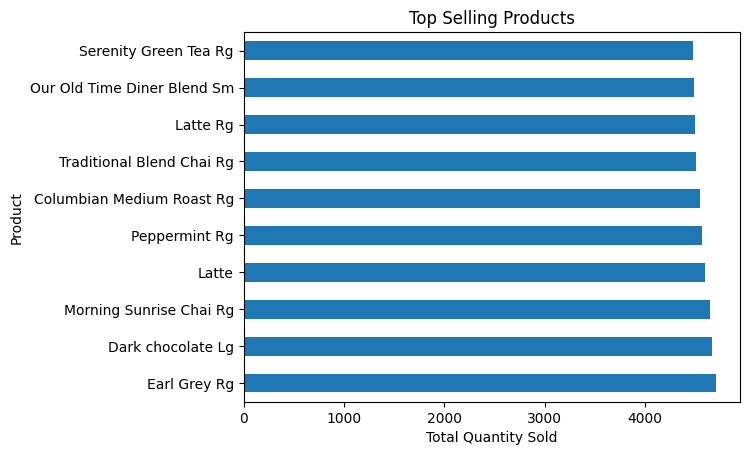

In [81]:
most_sold_product.head(10).plot(
    kind='barh',
    x='product_detail',
    y='transaction_qty',
    legend=False
)

plt.title("Top Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()

### Insight: Earl Grey Rg is the most liked product, so the store should focus on its quality and enhance it if possible 

##### Which product has the highest revenue ?

In [82]:
df['revenue'] = df['unit_price'] * df['transaction_qty']


In [83]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Hour,Minute,revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,6,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,8,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,14,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,20,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,22,6.2


In [84]:
highest_revenue_product = df.groupby('product_detail')['revenue'].sum().sort_values(ascending=False)
print(highest_revenue_product.head(10))

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: revenue, dtype: float64


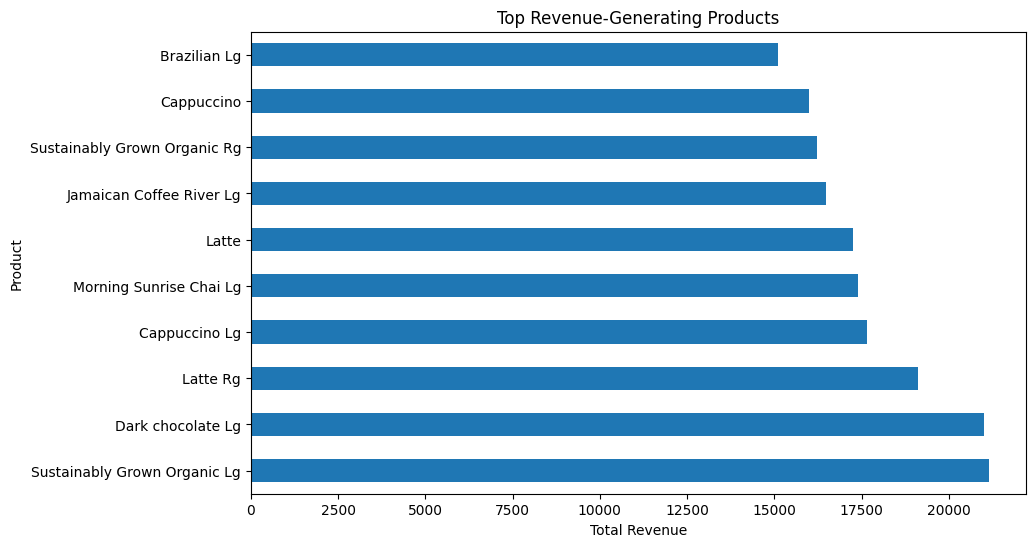

In [85]:
plt.figure(figsize=(10, 6))
highest_revenue_product.head(10).plot(
    kind='barh',
    x='product_detail',
    y='revenue',
    legend=False
)
plt.title("Top Revenue-Generating Products")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.show()

#### Which store location performs best revenue?

In [86]:
store_location_performs_best_revenue = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
print(store_location_performs_best_revenue)


store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64


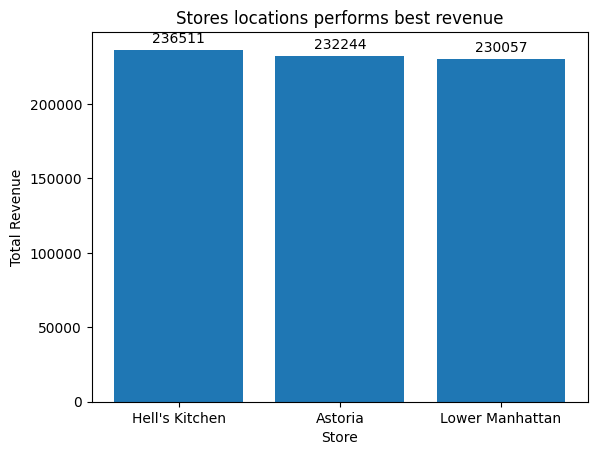

In [87]:
bars = plt.bar(store_location_performs_best_revenue.index,
               store_location_performs_best_revenue.values)

plt.title('Stores locations performs best revenue')
plt.xlabel("Store")
plt.ylabel('Total Revenue')

plt.bar_label(bars, fmt='%.0f', padding=3)

plt.show()

### Insight : Hell's Kitchen generate the highest revenue and overall performance, so it should be feed with sales staff to sustain service quality

#### What are the busiest hours?

In [88]:
print(df.columns.tolist())

['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'Hour', 'Minute', 'revenue']


In [89]:
busiest_hours = df.groupby('Hour').size().sort_values(ascending=False)
print(busiest_hours)

Hour
10    18545
9     17764
8     17654
7     13428
11     9766
16     9093
15     8979
14     8933
17     8745
13     8714
12     8708
18     7498
19     6092
6      4594
20      603
dtype: int64


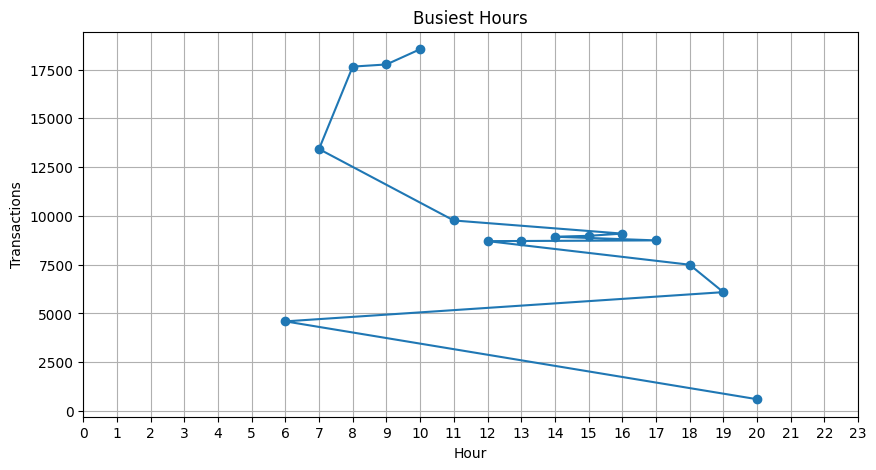

In [90]:
plt.figure(figsize=(10,5))
plt.plot(busiest_hours.index, busiest_hours.values, marker='o')
plt.title("Busiest Hours")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.xticks(range(0,24))
plt.grid()
plt.show()

#### How do sales vary over time?

In [91]:
sales_vary_over_time = df.groupby('Hour').size().reset_index(name='Transactions')

print(sales_vary_over_time)

    Hour  Transactions
0      6          4594
1      7         13428
2      8         17654
3      9         17764
4     10         18545
5     11          9766
6     12          8708
7     13          8714
8     14          8933
9     15          8979
10    16          9093
11    17          8745
12    18          7498
13    19          6092
14    20           603


In [92]:
fig = px.line(
    sales_vary_over_time,
    x='Hour',
    y='Transactions',
    markers=True,
    title='Sales vary over time'
)

fig.show()

#### insight: 8pm has the lowest sales, so the store can add some promotions to boost sales during that time, and 12pm has the highest sales, so the store should make sure to have enough staff and inventory to meet demand during that time.